In [ ]:
# !pip install -q kaggle
# !mkdir -p ~/.kaggle
# !cp '/content/drive/My Drive/kaggle.json' ~/.kaggle/
# !kaggle datasets download -d tinashri/brain-tumor-segmentation-datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !zip -r '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test.zip' '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test'

In [ ]:
# !unzip '/content/drive/MyDrive/PanoramicDental_DentalDataset.zip' -d '/content/drive/MyDrive/Datasets/PanoramicDental_DentalDataset'

In [ ]:
from fastai.vision.all import *
import os
import numpy as np
import tqdm as notebook_tqdm

**Convert Images**

In [ ]:
import cv2 as cv
import os

if __name__ == '__main__':
    lbl_dir = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Label'
    fixed_lbl_dir = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Fixed_Label'
    lbl_list = os.listdir(lbl_dir)

    # for img_name in lbl_list:
    #     lbl = cv.imread(os.path.join(lbl_dir, img_name))
    #     lbl = lbl/255
    #     # lbl = cv.resize(lbl, (150, 120))
    #     lbl_path = os.path.join(fixed_lbl_dir, img_name)
    #     cv.imwrite(lbl_path, lbl)
    #     # print(lbl_path)

**Preparing Data**

In [ ]:
def label_func(fn):
    path = '/content/drive/MyDrive/Datasets/PanoramicDental_DentalDataset/labels'
    return os.path.join(path, f"{fn.stem}.png")

path = '/content/drive/MyDrive/Datasets/PanoramicDental_DentalDataset'

codes = np.loadtxt(os.path.join(path, 'codes.txt'), dtype=str)
size = (150,120)

tfms = [Flip(),Brightness(0.1,p=0.25),Normalize.from_stats(*imagenet_stats)]
db = DataBlock(blocks=(ImageBlock(),MaskBlock(codes)),
               batch_tfms=tfms,
               item_tfms=[Resize(size)],
               get_items=get_image_files,
               get_y=label_func)
dls = db.dataloaders(os.path.join(path, 'images'), path=path,bs = 8)
# dls.show_batch(max_n=3)

In [ ]:
print('Number of training Images:',len(dls.train_ds))
print('Number of validation Images:',len(dls.valid_ds))

Number of training Images: 93
Number of validation Images: 23


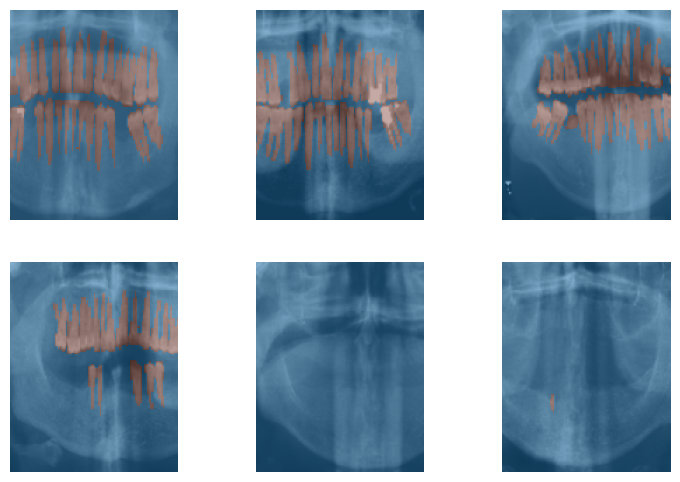

In [ ]:
dls.show_batch(max_n=6)

In [ ]:
learn = unet_learner(dls, resnet50, metrics=[Dice],cbs=[SaveModelCallback(),
                                                        ShowGraphCallback()])
# learn.lr_find()


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


epoch,train_loss,valid_loss,dice,time
0,0.555947,0.592043,0.000317,00:12
1,0.497942,0.500665,0.359138,00:12
2,0.430238,1.041248,0.144676,00:11
3,0.384270,0.303949,0.785907,00:12
4,0.343942,0.264344,0.811336,00:12
5,0.310631,0.241745,0.836052,00:12
6,0.282612,0.228161,0.848547,00:12
7,0.259493,0.214921,0.857298,00:12
8,0.240712,0.237709,0.845822,00:12
9,0.222515,0.186953,0.874582,00:13


Better model found at epoch 0 with valid_loss value: 0.5920434594154358.


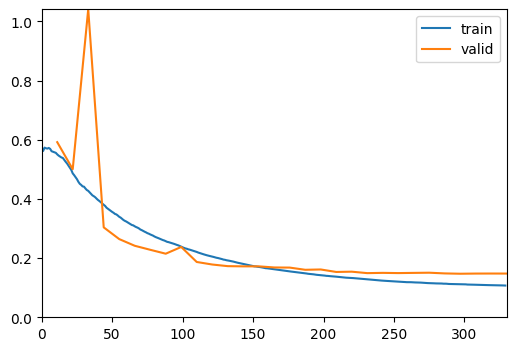

Better model found at epoch 1 with valid_loss value: 0.5006651878356934.
Better model found at epoch 3 with valid_loss value: 0.3039490282535553.
Better model found at epoch 4 with valid_loss value: 0.2643440365791321.
Better model found at epoch 5 with valid_loss value: 0.2417445331811905.
Better model found at epoch 6 with valid_loss value: 0.2281608134508133.
Better model found at epoch 7 with valid_loss value: 0.21492111682891846.
Better model found at epoch 9 with valid_loss value: 0.18695349991321564.
Better model found at epoch 10 with valid_loss value: 0.1783713400363922.
Better model found at epoch 11 with valid_loss value: 0.17285870015621185.
Better model found at epoch 12 with valid_loss value: 0.1721639782190323.
Better model found at epoch 14 with valid_loss value: 0.16840864717960358.
Better model found at epoch 15 with valid_loss value: 0.16796982288360596.
Better model found at epoch 16 with valid_loss value: 0.16053923964500427.
Better model found at epoch 18 with val

In [ ]:
learn.fit_one_cycle(1)

**Load Model**

In [ ]:
def label_func(fn):
    path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test/Label'
    return os.path.join(path, f"{fn.stem}.png")

model_path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/models/Model_train_loss_0_009_valid_loss_0_021_dice_0_8243_e12_E20_Resnet50'

path = '/content/drive/MyDrive/Datasets/brain-tumor-segmentation-datasets/data/Test'

codes = np.loadtxt(os.path.join(path, 'codes.txt'), dtype=str)
size = (150,120)

tfms = [Normalize.from_stats(*imagenet_stats)]
db = DataBlock(blocks=(ImageBlock(),MaskBlock(codes)),
               batch_tfms=tfms,
               item_tfms=[Resize(size)],
               get_items=get_image_files,
               get_y=label_func)
dls = db.dataloaders(os.path.join(path, 'Image'), path=path,bs = 8)
# dls.show_batch(max_n=3)

learn = unet_learner(dls, resnet50, metrics=[Dice])
learn = learn.load(model_path)
learn.summary()

In [ ]:
learn.show_results(ds_idx=10, dl=dls, max_n=3, figsize=(50,50))

In [ ]:
preds, targs = learn.get_preds(dl=dls)

**Test with CTScan Images**

In [ ]:
def label_func(fn):
    path = '/content/drive/MyDrive/Datasets/PanoramicDental_DentalDataset/labels'
    return os.path.join(path, f"{fn.stem}.png")

model_path = '/content/drive/MyDrive/Datasets/PanoramicDental_DentalDataset/models/resnet50'

path = '/content/drive/MyDrive/Datasets/PanoramicDental_DentalDataset'

codes = np.loadtxt(os.path.join(path, 'codes.txt'), dtype=str)
size = (150,120)

tfms = [Normalize.from_stats(*imagenet_stats)]
db = DataBlock(blocks=(ImageBlock(),MaskBlock(codes)),
               batch_tfms=tfms,
               item_tfms=[Resize(size)],
               get_items=get_image_files)
dls = db.dataloaders(os.path.join(path, 'images'), path=path,bs = 4)
# dls.show_batch(max_n=3)

learn = unet_learner(dls, resnet50, metrics=[Dice])
learn = learn.load(model_path)
learn.summary()

/usr/local/lib/python3.10/dist-packages/fastai/learner.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

DynamicUnet (Input shape: 4 x 3 x 150 x 120)
Layer (type)         Output Shape         Param #    Trainable 
                     4 x 64 x 75 x 60    
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     4 x 64 x 38 x 30    
MaxPool2d                                                      
Conv2d                                    4096       False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
____________________________________________________________________________
                     4 x 256 x 38 x 30   
Conv2d                                    16384      False     
BatchNorm2d                        

In [ ]:
from PIL import Image
import numpy as np
test_path = '/content/116.png'
img = np.array(Image.open(test_path).resize((120,150)))
print(img.shape)
cat, tensor, probs = learn.predict(img)


(150, 120)


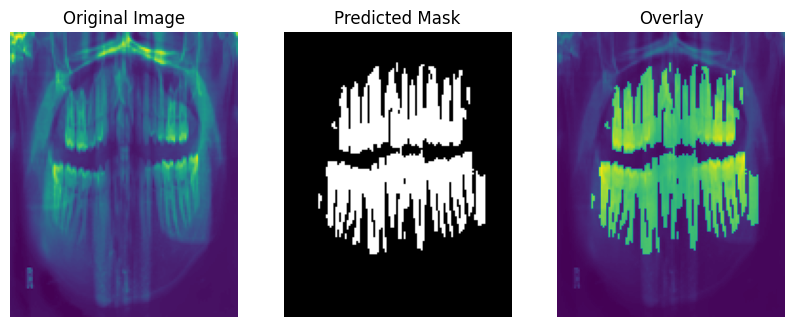

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert predicted_mask to a color map
mask_color = np.zeros((*tensor.shape), dtype=np.uint8)
mask_color[tensor == 1] = [255, 0, 0]  # Red for class 1, adjust as necessary

# Overlay the mask on the original image
overlay = np.array(img) * 0.5 + mask_color * 0.5  # Blend images

# Display the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Predicted Mask")
plt.imshow(tensor, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay.astype(np.uint8))
plt.axis('off')

plt.show()

In [ ]:
print(cat)
print(tensor)
print(probs, probs.shape)

In [ ]:
print(img.shape)
print(img.ndim)

print(np.array(cat).shape)
print(np.array(cat).ndim)

(150, 120)
2
(150, 120)
2


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print(probs.shape)
probs2 = np.transpose(probs, (1, 2, 0))
print(probs2.shape, img.shape)
img2 = np.stack([img, np.array(probs2)])
# img2 = np.transpose(img2, (1, 2, 0))
plt.imshow(img2)
plt.show()


In [ ]:
dls.cat

In [ ]:
preds, targs = learn.get_preds(dl=dls)